### 07 - Neural Network (MLP)

MLPRegressor to predict demand_log. Same features and scaling as the SVM.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13})
os.makedirs('../outputs/figures/07_nn', exist_ok=True)

df = pd.read_csv('../data/processed/hourly_merged.csv', index_col='datetime_utc')
df.index = pd.to_datetime(df.index, utc=True)

FEATURES = ['T', 'Hr', 'StrGlo', 'RainDur', 'WVv', 'p',
            'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'is_weekend']

df = df.dropna(subset=FEATURES)

#### 1. Train / Test Split and Scaling

In [2]:
train = df[df.index.year < 2025]
test  = df[df.index.year == 2025]

scaler  = StandardScaler()
X_train = scaler.fit_transform(train[FEATURES].values)
y_train = train['demand_log'].values
X_test  = scaler.transform(test[FEATURES].values)
y_test  = test['demand_log'].values

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')

Train: 26,260  |  Test: 8,748


#### 2. Architecture Comparison

In [3]:
architectures = {
    '(64,32)':      (64, 32),
    '(128,64)':     (128, 64),
    '(128,64,32)':  (128, 64, 32),
}

trained = {}
for name, layers in architectures.items():
    mlp = MLPRegressor(
        hidden_layer_sizes=layers,
        activation='relu',
        solver='adam',
        early_stopping=True,
        validation_fraction=0.1,
        max_iter=500,
        random_state=42
    )
    mlp.fit(X_train, y_train)
    trained[name] = mlp
    # best_loss_ is None in sklearn 1.8, use min of loss_curve_ instead
    best_loss = min(mlp.loss_curve_)
    print(f'{name:15s}  best_loss={best_loss:.5f}  epochs={mlp.n_iter_}')

(64,32)          best_loss=0.00159  epochs=120


(128,64)         best_loss=0.00173  epochs=63


(128,64,32)      best_loss=0.00152  epochs=91


In [4]:
best_name = min(trained, key=lambda k: min(trained[k].loss_curve_))
best_mlp  = trained[best_name]
print(f'Best architecture: {best_name}')

Best architecture: (128,64,32)


#### 3. Loss Curves

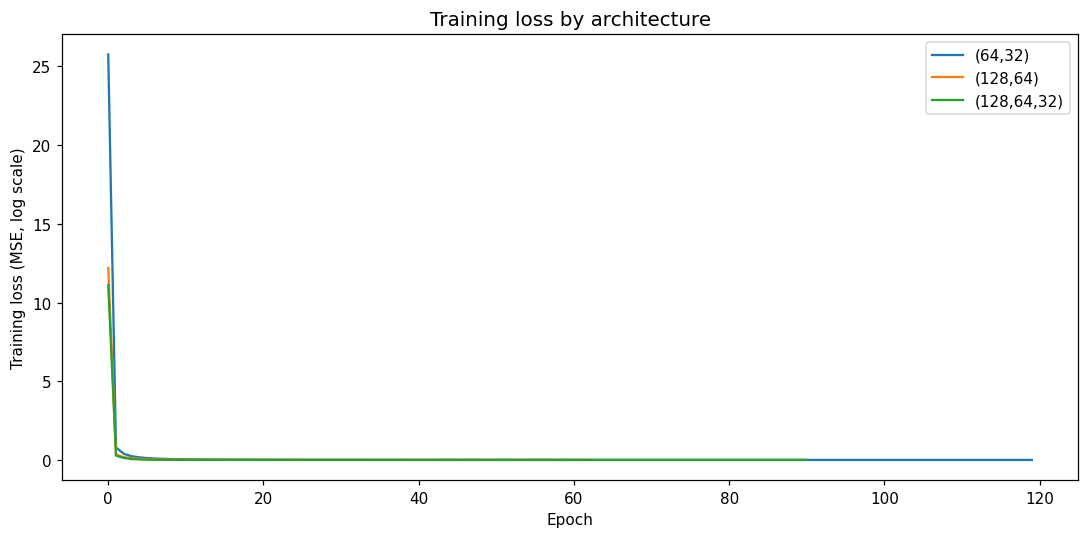

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, mlp in trained.items():
    ax.plot(mlp.loss_curve_, label=name, lw=1.5)

ax.set_xlabel('Epoch')
ax.set_ylabel('Training loss (MSE, log scale)')
ax.set_title('Training loss by architecture')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/07_nn/07_17_nn_loss_curves.png', bbox_inches='tight')
plt.show()

#### 4. Test Set Predictions

In [6]:
y_pred_log = best_mlp.predict(X_test)
y_pred     = np.exp(y_pred_log)
y_actual   = np.exp(y_test)

rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
mae  = mean_absolute_error(y_actual, y_pred)

print(f'Best arch : {best_name}')
print(f'RMSE : {rmse:,.1f} kW  ({rmse / y_actual.mean() * 100:.1f}% of mean)')
print(f'MAE  : {mae:,.1f} kW  ({mae  / y_actual.mean() * 100:.1f}% of mean)')

Best arch : (128,64,32)
RMSE : 5,384.1 kW  (7.3% of mean)
MAE  : 3,791.8 kW  (5.1% of mean)


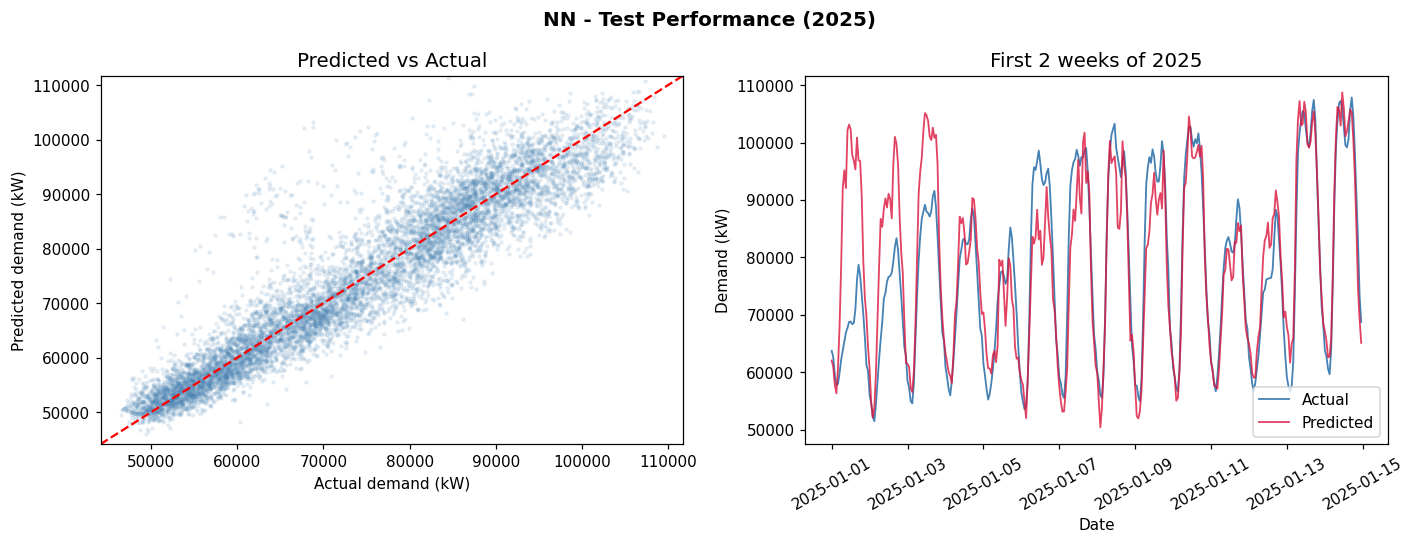

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

lim = [y_actual.min() * 0.95, y_actual.max() * 1.02]
axes[0].scatter(y_actual, y_pred, alpha=0.1, s=4, color='steelblue')
axes[0].plot(lim, lim, 'r--', lw=1.5)
axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel('Actual demand (kW)')
axes[0].set_ylabel('Predicted demand (kW)')
axes[0].set_title('Predicted vs Actual')

# same 2-week window as LM, GAM, SVM
two_weeks   = test.iloc[:24*14]
X_tw        = scaler.transform(two_weeks[FEATURES].values)
y_tw_pred   = np.exp(best_mlp.predict(X_tw))
y_tw_actual = np.exp(two_weeks['demand_log'].values)

axes[1].plot(two_weeks.index, y_tw_actual, lw=1.2, label='Actual',    color='steelblue')
axes[1].plot(two_weeks.index, y_tw_pred,   lw=1.2, label='Predicted', color='crimson', alpha=0.8)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Demand (kW)')
axes[1].set_title('First 2 weeks of 2025')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=30)

fig.suptitle('NN - Test Performance (2025)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/07_nn/07_18_nn_pred_vs_actual.png', bbox_inches='tight')
plt.show()

#### 5. Save Metrics

In [8]:
new_row = pd.DataFrame([{
    'model':    f'NN {best_name}',
    'rmse':     round(rmse, 1),
    'mae':      round(mae, 1),
    'r2_train': np.nan,
    'auc':      np.nan
}])

out = '../outputs/model_comparison.csv'
if os.path.exists(out):
    existing = pd.read_csv(out)
    existing = existing[~existing['model'].str.startswith('NN')]
    new_row = pd.concat([existing, new_row], ignore_index=True)

new_row.to_csv(out, index=False)
print(new_row.to_string())

            model      rmse       mae  r2_train     auc
0              LM  7623.700  6125.800    0.7855     NaN
1     GLM_Poisson     2.575     1.441    0.6887     NaN
2    GLM_Binomial       NaN       NaN    0.5254  0.9593
3             GAM  7199.800  5829.100    0.8081     NaN
4             SVM  4768.800  3481.300       NaN     NaN
5  NN (128,64,32)  5384.100  3791.800       NaN     NaN
